# logic1 Results Charts

This notebook loads `logic1_results.csv` and creates two time-series charts.
The performance chart uses actual chiller cooling for the kW/TR calculation and plots actual chiller cooling as the load reference.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

CSV_PATH = Path("logic1_results.csv")
if not CSV_PATH.exists():
    CSV_PATH = Path.cwd() / "logic1_results.csv"

results = pd.read_csv(CSV_PATH)
results["timestamp"] = pd.to_datetime(results["timestamp"])
time_hours = results["elapsed_minutes"] / 60

if "chiller_1_dT_degC" not in results.columns:
    results["chiller_1_dT_degC"] = results["chiller_1_inlet_temp_degC"] - results["chiller_1_outlet_temp_degC"]
if "chiller_2_dT_degC" not in results.columns:
    results["chiller_2_dT_degC"] = results["chiller_2_inlet_temp_degC"] - results["chiller_2_outlet_temp_degC"]

active_chiller_1 = results["chiller_1_status"].str.lower().eq("on") & results["chiller_1_mass_flow_kg_s"].gt(0.01)
active_chiller_2 = results["chiller_2_status"].str.lower().eq("on") & results["chiller_2_mass_flow_kg_s"].gt(0.01)
results["chiller_1_dT_active_degC"] = results["chiller_1_dT_degC"].where(active_chiller_1)
results["chiller_2_dT_active_degC"] = results["chiller_2_dT_degC"].where(active_chiller_2)

results.head()

,timestamp,time_s,elapsed_minutes,outdoor_temp_degC,room_internal_heat_gain_kW,room_internal_heat_gain_TR,chiller_1_status,chiller_1_inlet_temp_degC,chiller_1_outlet_temp_degC,chiller_1_dT_degC,chiller_1_mass_flow_kg_s,chiller_1_actual_cooling_kW,chiller_1_actual_cooling_TR,chiller_2_status,chiller_2_inlet_temp_degC,chiller_2_outlet_temp_degC,chiller_2_dT_degC,chiller_2_mass_flow_kg_s,chiller_2_actual_cooling_kW,chiller_2_actual_cooling_TR,actual_total_chiller_cooling_kW,actual_total_chiller_cooling_TR,cooling_tower_1_heat_extracted_kW,cooling_tower_2_heat_extracted_kW,cooling_tower_total_heat_extracted_kW,chiller_1_power_kW,chiller_2_power_kW,chiller_total_power_kW,chw_pump_1_power_kW,chw_pump_2_power_kW,cw_pump_1_power_kW,cw_pump_2_power_kW,pump_total_power_kW,cooling_tower_fan_total_power_kW,water_side_total_power_kW,chiller_performance_actual_kW_per_TR,plant_performance_actual_kW_per_TR,chiller_performance_room_gain_kW_per_TR,plant_performance_room_gain_kW_per_TR,chiller_1_dT_active_degC,chiller_2_dT_active_degC
0,2001-06-01 00:00:00,13046400,0,11.600000,200,56.869033,on,20.000000,20,0.000000,4.761905,0.000000,0.000000,off,20,20,0,0,0,0,0.000000,0.000000,0.000000,0,0.000000,42.260692,0,42.260692,3.918110,0,6.995309,0,10.913419,6,59.174111,NaN,NaN,0.743123,1.040533,0.000000,NaN
1,2001-06-01 00:05:00,13046700,5,11.566667,200,56.869033,on,5.079009,5,0.079009,4.761905,1.580173,0.449314,off,20,20,0,0,0,0,1.580173,0.449314,11.041451,0,11.041451,0.225835,0,0.225835,1.573944,0,6.995309,0,8.569252,6,14.795087,NaN,NaN,0.003971,0.260161,0.079009,NaN
2,2001-06-01 00:10:00,13047000,10,11.533333,200,56.869033,on,5.038664,5,0.038664,3.327931,0.540421,0.153666,off,20,20,0,0,0,0,0.540421,0.153666,1.259626,0,1.259626,0.076809,0,0.076809,0.537242,0,6.995309,0,7.532551,6,13.609359,NaN,NaN,0.001351,0.239311,0.038664,NaN
3,2001-06-01 00:15:00,13047300,15,11.500000,200,56.869033,on,5.028130,5,0.028130,2.839956,0.335530,0.095406,off,20,20,0,0,0,0,0.335530,0.095406,0.803906,0,0.803906,0.047661,0,0.047661,0.333873,0,6.995309,0,7.329182,6,13.376843,NaN,NaN,0.000838,0.235222,0.028130,NaN
4,2001-06-01 00:20:00,13047600,20,11.466667,200,56.869033,on,5.020690,5,0.020690,2.435393,0.211630,0.060176,off,20,20,0,0,0,0,0.211630,0.060176,0.689816,0,0.689816,0.030027,0,0.030027,0.210549,0,6.995309,0,7.205858,6,13.235886,NaN,NaN,0.000528,0.232743,0.020690,NaN


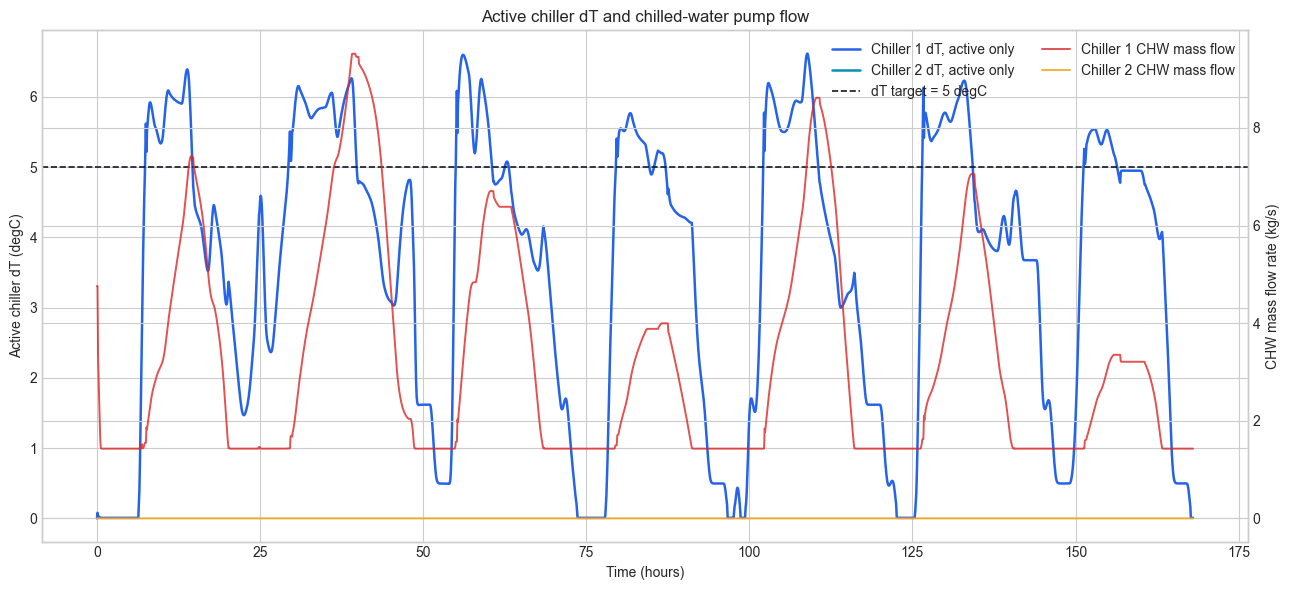

In [2]:
fig, ax_dt = plt.subplots(figsize=(13, 6))

ax_dt.plot(time_hours, results["chiller_1_dT_active_degC"], label="Chiller 1 dT, active only", color="#2563eb", linewidth=1.8)
ax_dt.plot(time_hours, results["chiller_2_dT_active_degC"], label="Chiller 2 dT, active only", color="#0891b2", linewidth=1.8)
ax_dt.axhline(5, color="#111827", linestyle="--", linewidth=1.2, label="dT target = 5 degC")
ax_dt.set_xlabel("Time (hours)")
ax_dt.set_ylabel("Active chiller dT (degC)")

ax_flow = ax_dt.twinx()
ax_flow.plot(time_hours, results["chiller_1_mass_flow_kg_s"], label="Chiller 1 CHW mass flow", color="#dc2626", linewidth=1.4, alpha=0.8)
ax_flow.plot(time_hours, results["chiller_2_mass_flow_kg_s"], label="Chiller 2 CHW mass flow", color="#f59e0b", linewidth=1.4, alpha=0.8)
ax_flow.set_ylabel("CHW mass flow rate (kg/s)")

lines = ax_dt.get_lines() + ax_flow.get_lines()
labels = [line.get_label() for line in lines]
ax_dt.legend(lines, labels, loc="upper right", ncol=2)
ax_dt.set_title("Active chiller dT and chilled-water pump flow")
fig.tight_layout()
plt.show()


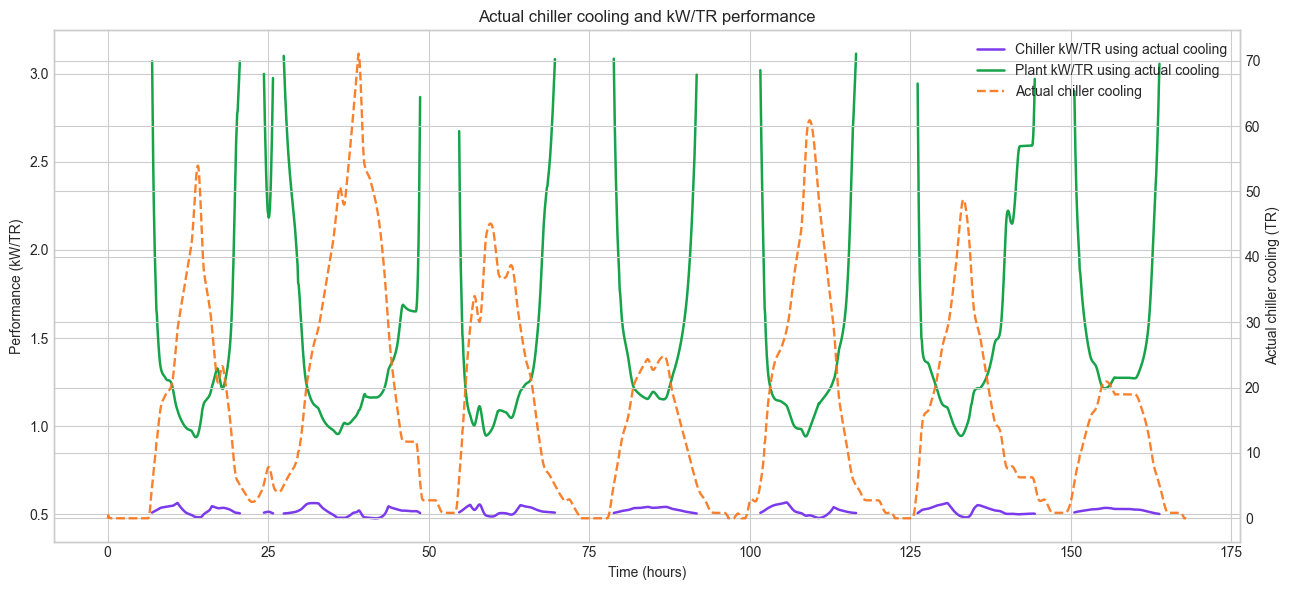

In [3]:
fig, ax_perf = plt.subplots(figsize=(13, 6))

ax_perf.plot(time_hours, results["chiller_performance_actual_kW_per_TR"], label="Chiller kW/TR using actual cooling", color="#7c3aed", linewidth=1.8)
ax_perf.plot(time_hours, results["plant_performance_actual_kW_per_TR"], label="Plant kW/TR using actual cooling", color="#16a34a", linewidth=1.8)
ax_perf.set_xlabel("Time (hours)")
ax_perf.set_ylabel("Performance (kW/TR)")

ax_load = ax_perf.twinx()
ax_load.plot(time_hours, results["actual_total_chiller_cooling_TR"], label="Actual chiller cooling", color="#f97316", linewidth=1.7, linestyle="--", alpha=0.9)
ax_load.set_ylabel("Actual chiller cooling (TR)")

lines = ax_perf.get_lines() + ax_load.get_lines()
labels = [line.get_label() for line in lines]
ax_perf.legend(lines, labels, loc="upper right")
ax_perf.set_title("Actual chiller cooling and kW/TR performance")
fig.tight_layout()
plt.show()
